# Warm-up — Where does the Earth shake?

**AI-integrated Sustainable Finance (25881) · before Lecture 7**

---

No ESG data in this notebook. No finance. Just a simple question:

> **The Earth shook about three thousand times last month. Where?**

Along the way you will build every tool Lecture 7 depends on — interactive
maps, clustering, silhouette scores, distance metrics — on data where you can
*see* whether the answer is right. That is the point. When we do the same
thing to corporate emissions next week, you will have no idea whether the
clusters are sensible unless you already know what a sensible cluster looks
like.

### The plan

1. Ten lines of Python turn a URL into a world map. **(5 minutes)**
2. Guess how many seismic regions there are. Write it down.
3. Ask a machine. It will confidently give you the **wrong** answer.
4. Work out why: one wrong assumption about shape, one wrong assumption about
   distance.
5. Fix both, and watch the algorithm draw the tectonic plates.
6. Discover that the map of earthquakes is partly a map of *seismometers* —
   which is the idea Lecture 7 is built on.

### Requirements

`pandas`, `numpy`, `scikit-learn`, `plotly`, `folium`. Data comes from the
USGS real-time feed, which needs no API key. If the network is down the
notebook falls back through a cache, then a mirror, then generated data, and
tells you which it used.

In [2]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"

import folium
from folium.plugins import HeatMap

import quakedata as qd

# Optional. Every widget cell below has a plain-variable fallback.
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

print(f"folium {folium.__version__} | ipywidgets available: {HAS_WIDGETS}")

folium 0.20.0 | ipywidgets available: True


---
## 1. Ten lines to a world map

This is the whole pipeline: fetch, parse, plot.

In [3]:
quakes, prov = qd.fetch_quakes("2.5_month")

print(f"\nsource:    {prov['source']}")
print(f"events:    {prov['n']:,}")
if prov["source"] == "synthetic":
    print("\n" + "!" * 68)
    print(prov["warning"])
    print("!" * 68)

quakes.head()

[live]   2,173 events from USGS, cached to _cache\usgs_2.5_month.csv

source:    live
events:    2,173


,id,time,place,mag,magType,lon,lat,depth_km,net,type,tsunami,sig
0,us7000td2f,2026-08-31 04:38:22.200000+00:00,south of the Fiji Islands,4.50,mb,179.802100,-25.206500,508.306,us,earthquake,0,312
1,us7000td2c,2026-08-31 04:04:34.127000+00:00,"13 km SSE of Union, Philippines",4.90,mb,126.136200,9.640800,83.891,us,earthquake,0,370
2,ci41539488,2026-08-31 02:16:31.390000+00:00,"2 km NW of Delta, B.C., MX",2.63,ml,-115.211000,32.368500,17.870,ci,earthquake,0,106
3,us7000td1g,2026-08-31 01:08:05.874000+00:00,"71 km WSW of Puerto Casma, Peru",4.50,mb,-79.014500,-9.615200,59.386,us,earthquake,0,312
4,pr71530403,2026-08-31 00:42:28.180000+00:00,"1 km WSW of Guayanilla, Puerto Rico",2.88,md,-66.809167,18.013333,16.660,pr,earthquake,0,128


Look at the `source` line. It says `live`, `cache`, `mirror` or `synthetic`,
and **you should read it every time**. A notebook that silently substitutes
generated data for real data has told you something false about the world, and
nothing downstream will complain.

That habit — check the provenance before you trust the numbers — is the first
thing Lecture 7 asks of you.

In [5]:
m = folium.Map(location=[10, 120], zoom_start=2, tiles="OpenStreetMap",               # "OpenStreetMap" or "OpenTopoMap"
               attr="Map data: OpenStreetMap contributors, SRTM | "
                    "Style: OpenTopoMap (CC-BY-SA)")

for _, r in quakes.iterrows():
    folium.CircleMarker(
        [r["lat"], r["lon"]],
        radius=1.2 * float(r["mag"]),
        color="#d62728", weight=0, fill=True, fill_opacity=0.35,
        popup=f"M{r['mag']} · {r['place']}",
    ).add_to(m)

m

Ten lines. Zoom out, then zoom into the western Pacific.

**Now look at the terrain underneath the dots.** OpenTopoMap renders relief, and
the earthquakes trace the trenches and mountain chains almost exactly. The
basemap is telling you the same story as the data, from a completely
independent source. Hold on to that — cross-checking one dataset against
another with different failure modes is a recurring theme next week.

---
## 2. Look before you model

Two quick plots. Both say something about the physics, and one is a trap.

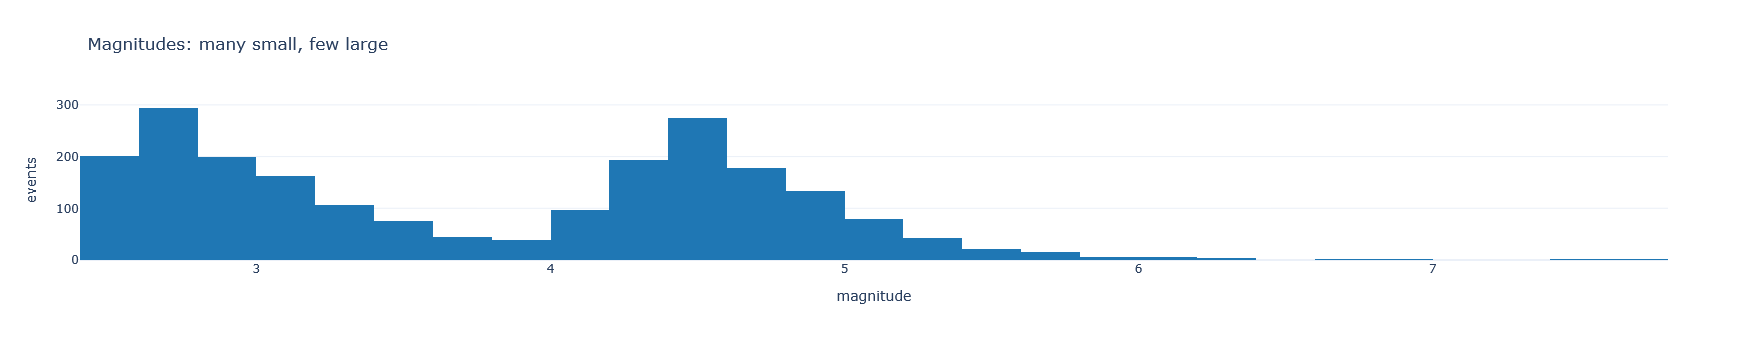

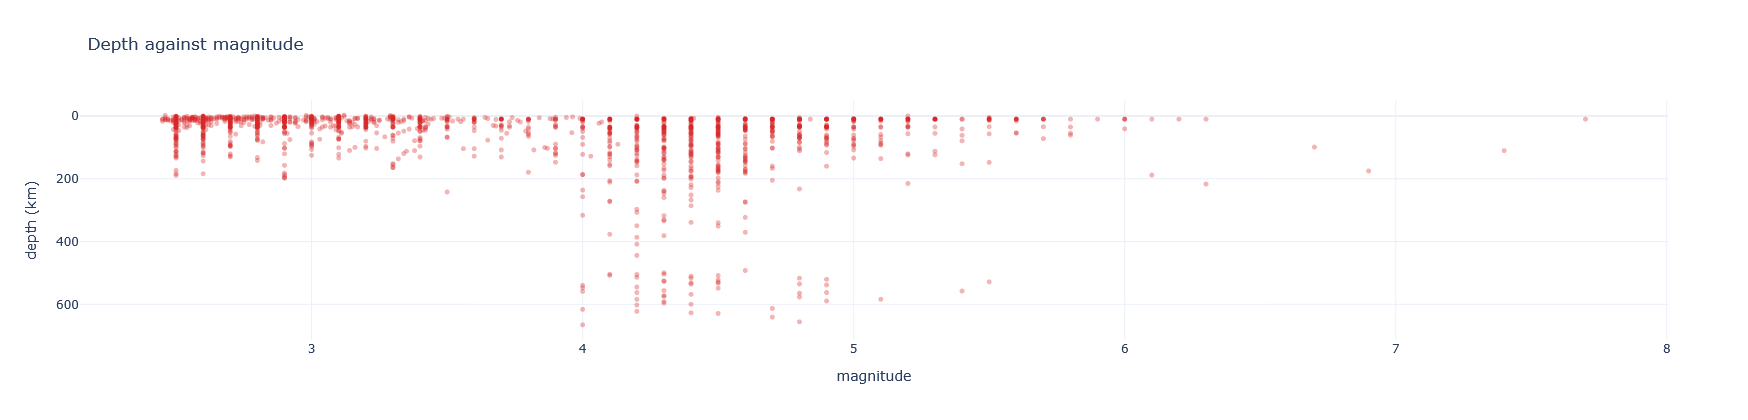

magnitude: min 2.5, median 3.8, max 7.7
depth:     median 12 km, deepest 665 km


In [6]:
fig = px.histogram(quakes, x="mag", nbins=45,
                   title="Magnitudes: many small, few large",
                   labels={"mag": "magnitude"})
fig.update_traces(marker_color="#1f77b4")
fig.update_layout(height=340, yaxis_title="events")
fig.show()

fig = px.scatter(quakes, x="mag", y="depth_km", opacity=0.35,
                 title="Depth against magnitude",
                 labels={"mag": "magnitude", "depth_km": "depth (km)"})
fig.update_yaxes(autorange="reversed")
fig.update_traces(marker=dict(size=5, color="#d62728"))
fig.update_layout(height=420)
fig.show()

print(f"magnitude: min {quakes['mag'].min():.1f}, "
      f"median {quakes['mag'].median():.1f}, max {quakes['mag'].max():.1f}")
print(f"depth:     median {quakes['depth_km'].median():.0f} km, "
      f"deepest {quakes['depth_km'].max():.0f} km")

The magnitude histogram falls away sharply — that is the Gutenberg–Richter
relation, and it is roughly log-linear.

**The trap:** the histogram starts at 2.5 not because small earthquakes are
rare, but because we asked for the `2.5_month` feed. The shape of your data
was determined by a filter you chose, before you saw any of it. We come back
to this in Section 7.

---
## 3. Commit to a guess

Before running any algorithm: **how many distinct seismic regions do you think
there are?**

Not how many earthquakes. How many coherent *belts* — places where quakes form
a connected chain rather than scattered dots.

Write your number down now. Committing before you see the answer is the only
way to find out whether your intuition was any good, and it is much harder to
fool yourself afterwards.

In [7]:
def record_guess(n_regions=8):
    print(f"Your guess: {n_regions} seismic regions")
    print("Now scroll on. We will check it twice: once with a method that")
    print("gets it wrong, and once with a method that gets it right.")
    return n_regions


if HAS_WIDGETS:
    widgets.interact(record_guess,
                     n_regions=widgets.IntSlider(min=2, max=25, value=8,
                                                 description="my guess",
                                                 continuous_update=False))
else:
    MY_GUESS = 8          # FALLBACK: edit this number, then run the cell
    record_guess(MY_GUESS)

interactive(children=(IntSlider(value=8, continuous_update=False, description='my guess', max=25, min=2), Outp…

---
## 4. Ask a machine: $k$-means

$k$-means is the clustering algorithm everyone learns first. Give it a number
of clusters, and it partitions the data by nearest centroid.

We do not know the right number, so we will use the standard trick: run it for
many values of $k$ and pick the one with the best **silhouette score**.

<details>
<summary><b>Maths: The silhouette coefficient</b> (click to expand)</summary>

For a point $i$ in cluster $C$, let $a_i$ be the mean distance to the other
points of $C$, and $b_i$ the lowest mean distance to any *other* cluster. Then

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1].$$

Near $+1$: comfortably inside its own cluster. Near $0$: on a boundary. Negative:
probably assigned to the wrong one. The score for a whole partition is the mean
of $s_i$.

Note what it measures: **how tight and well-separated the groups are, in the
distance you gave it**. It has no idea what the points mean.

</details>

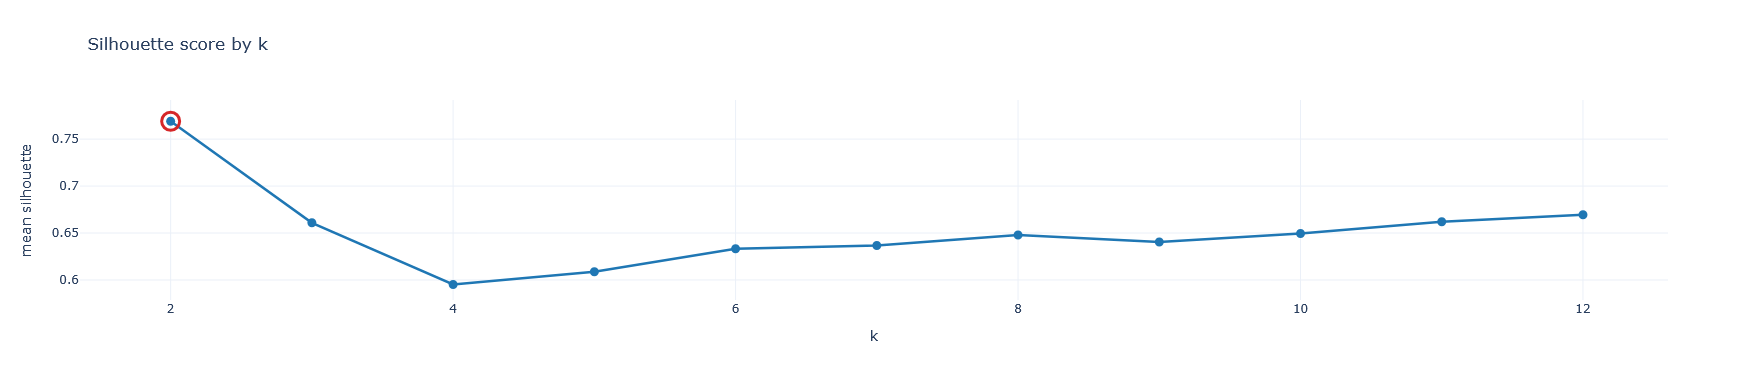

Silhouette is highest at k = 2  (score 0.769)
How did that compare with your guess?


In [8]:
X = quakes[["lat", "lon"]].to_numpy()

ks = range(2, 13)
sils, inertias = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    sils.append(silhouette_score(X, km.labels_))
    inertias.append(km.inertia_)

best_k = list(ks)[int(np.argmax(sils))]

fig = go.Figure(go.Scatter(x=list(ks), y=sils, mode="lines+markers",
                           line=dict(color="#1f77b4", width=2.5),
                           marker=dict(size=9)))
fig.add_trace(go.Scatter(x=[best_k], y=[max(sils)], mode="markers",
                         marker=dict(size=18, color="#d62728",
                                     symbol="circle-open", line=dict(width=3)),
                         showlegend=False))
fig.update_layout(title="Silhouette score by k", xaxis_title="k",
                  yaxis_title="mean silhouette", height=380, showlegend=False)
fig.show()

print(f"Silhouette is highest at k = {best_k}  (score {max(sils):.3f})")
print(f"How did that compare with your guess?")

The curve has a clear winner, and the method looks like it has answered the
question. Let us put that partition on the map.

In [9]:
kmodel = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(X)
quakes["kmeans"] = kmodel.labels_

PALETTE = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4",
           "#f032e6", "#bfef45", "#469990", "#9a6324", "#800000", "#000075"]

m2 = folium.Map(location=[10, 150], zoom_start=2, tiles="OpenStreetMap")
for _, r in quakes.iterrows():
    folium.CircleMarker(
        [r["lat"], r["lon"]], radius=3,
        color=PALETTE[int(r["kmeans"]) % len(PALETTE)],
        weight=0, fill=True, fill_opacity=0.6,
    ).add_to(m2)

# Mark the centroids so the geometry is unmistakable
for c in kmodel.cluster_centers_:
    folium.CircleMarker([c[0], c[1]], radius=9, color="black", weight=2,
                        fill=True, fill_color="white",
                        fill_opacity=0.9).add_to(m2)
m2

### Now look carefully

Zoom to the western Pacific and follow one colour.

The clusters are **circular blobs**. They cut straight across the Ring of Fire,
lumping Japan with parts of Siberia, splitting the South American trench in the
middle for no physical reason. The black centroids sit in the ocean, in places
where nothing has ever happened.

The silhouette score was perfectly happy. It is measuring whether the groups are
compact and separated — and by that standard, blobs are excellent.

**Two things went wrong, and both matter next week.**

---
## 5. Problem one: the shape assumption

$k$-means assigns every point to the nearest centroid, so its clusters are
always convex blobs. That is fine for detecting, say, three separate cities. It
is hopeless for a feature that is **long, thin and curved** — which is exactly
what a plate boundary is.

There is a second, quieter problem. $k$-means must assign *every* point to a
cluster. There is no way for it to say "this earthquake is on its own in the
middle of a continental plate and belongs to nothing."

In [10]:
# How isolated is the most isolated event, and what did k-means do with it?
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=6, metric="haversine")
nn.fit(np.radians(X))
d, _ = nn.kneighbors(np.radians(X))
quakes["km_to_5th_neighbour"] = d[:, -1] * 6371

loners = quakes.nlargest(8, "km_to_5th_neighbour")
print("The eight most isolated earthquakes:\n")
print(loners[["place", "mag", "km_to_5th_neighbour", "kmeans"]]
      .rename(columns={"km_to_5th_neighbour": "km_to_5th_nbr"})
      .round(0).to_string(index=False))
print("\nEvery one of them was still assigned to a cluster.")
print("k-means has no vocabulary for 'this belongs to nothing'.")

The eight most isolated earthquakes:

                       place  mag  km_to_5th_nbr  kmeans
      southeast Indian Ridge  5.0         4177.0       1
Prince Edward Islands region  4.0         3565.0       1
      Southwest Indian Ridge  5.0         3218.0       1
     Pacific-Antarctic Ridge  4.0         3196.0       0
Indian Ocean Triple Junction  5.0         3133.0       1
     Pacific-Antarctic Ridge  5.0         3130.0       0
 northern Mid-Atlantic Ridge  5.0         2980.0       0
             south of Africa  5.0         2964.0       1

Every one of them was still assigned to a cluster.
k-means has no vocabulary for 'this belongs to nothing'.


---
## 6. Problem two: degrees are not distance

We handed the algorithm columns called `lat` and `lon` and let it compute
ordinary straight-line distance between them. That is wrong in two separate
ways.

In [11]:
print("How far is one degree of longitude?\n")
equator_km = qd.haversine_km(0, 0, 0, 1)
for lat in [0, 20, 40, 60, 70, 80]:
    deg_km = qd.haversine_km(lat, 0, lat, 1)
    print(f"  at latitude {lat:2d}°: {deg_km:6.1f} km"
          f"   ({deg_km / equator_km:.0%} of its length at the equator)")

print("\nA degree of latitude is always about 111 km.")
print("So on raw lat/lon, a cluster near the poles is stretched horizontally")
print("by a factor of three or more compared with one at the equator.")

How far is one degree of longitude?

  at latitude  0°:  111.2 km   (100% of its length at the equator)
  at latitude 20°:  104.5 km   (94% of its length at the equator)
  at latitude 40°:   85.2 km   (77% of its length at the equator)
  at latitude 60°:   55.6 km   (50% of its length at the equator)
  at latitude 70°:   38.0 km   (34% of its length at the equator)
  at latitude 80°:   19.3 km   (17% of its length at the equator)

A degree of latitude is always about 111 km.
So on raw lat/lon, a cluster near the poles is stretched horizontally
by a factor of three or more compared with one at the equator.


In [12]:
# The second failure is more dramatic.
tonga = (-20.0, -175.0)
fiji = (-22.0, 179.0)

true_km = qd.haversine_km(*tonga, *fiji)
naive_deg = np.hypot(tonga[0] - fiji[0], tonga[1] - fiji[1])

print(f"Tonga  {tonga}")
print(f"Fiji   {fiji}")
print(f"\n  true great-circle distance : {true_km:,.0f} km")
print(f"  naive straight-line on degrees: {naive_deg:.0f} 'degrees'"
      f"  -> about {naive_deg * 111:,.0f} km if you believed it")
print(f"\n  overstated by a factor of {(naive_deg * 111) / true_km:.0f}")
print("\nThey are neighbours. Euclidean distance on longitude thinks they are")
print("nearly on opposite sides of the planet, because +179 and -175 look far")
print("apart as numbers. This is the antimeridian, and it silently cuts the")
print("Ring of Fire in half.")

Tonga  (-20.0, -175.0)
Fiji   (-22.0, 179.0)

  true great-circle distance : 661 km
  naive straight-line on degrees: 354 'degrees'  -> about 39,295 km if you believed it

  overstated by a factor of 59

They are neighbours. Euclidean distance on longitude thinks they are
nearly on opposite sides of the planet, because +179 and -175 look far
apart as numbers. This is the antimeridian, and it silently cuts the
Ring of Fire in half.


<details>
<summary><b>Maths: The haversine distance</b> (click to expand)</summary>

For two points $(\phi_1,\lambda_1)$ and $(\phi_2,\lambda_2)$ in **radians**,
with $\Delta\phi=\phi_2-\phi_1$ and $\Delta\lambda=\lambda_2-\lambda_1$:

$$a=\sin^2\!\Big(\tfrac{\Delta\phi}{2}\Big)+\cos\phi_1\cos\phi_2\,
      \sin^2\!\Big(\tfrac{\Delta\lambda}{2}\Big),
\qquad d = 2R\arcsin\!\big(\sqrt{a}\big)$$

with $R\approx 6371$ km. The $\cos\phi_1\cos\phi_2$ term is what shrinks a
degree of longitude as you move away from the equator, and the trigonometry
wraps correctly across the antimeridian.

`scikit-learn`'s `metric="haversine"` expects **radians** and returns distance
on the **unit sphere**, so a radius in kilometres must be divided by $R$:

$$\varepsilon_{\text{rad}} = \varepsilon_{\text{km}} / 6371$$

Forget the conversion and your neighbourhood is 6371 times too big, which
produces exactly one enormous cluster.

</details>

---
## 7. Fix both: DBSCAN on the sphere

`DBSCAN` fixes the shape problem: it grows clusters outwards from dense
regions, so a cluster can be any shape at all — including a 10,000 km arc. It
also labels sparse points as **noise** (`-1`), which gives it the vocabulary
$k$-means lacked.

And `metric="haversine"` fixes the distance problem.

Two parameters:

* `eps` — the neighbourhood radius. We express it in km and convert.
* `min_samples` — how many neighbours make a point "core".

Neither is the number of clusters. **You do not tell DBSCAN how many groups to
find.** It tells you.

In [15]:
XR = np.radians(X)


def run_dbscan(eps_km=400, min_samples=4):
    lab = DBSCAN(eps=eps_km / 6371.0, min_samples=min_samples,
                 metric="haversine").fit_predict(XR)
    n_clusters = len(set(lab) - {-1})
    n_noise = int((lab == -1).sum())

    mm = folium.Map(location=[10, 150], zoom_start=2, tiles="OpenStreetMap",
                    attr="Map data: OpenStreetMap contributors, SRTM | "
                         "Style: OpenTopoMap (CC-BY-SA)")
    for (la, lo), l in zip(X, lab):
        if l == -1:
            folium.CircleMarker([la, lo], radius=2, color="#808080", weight=0,
                                fill=True, fill_opacity=0.45).add_to(mm)
        else:
            folium.CircleMarker([la, lo], radius=3,
                                color=PALETTE[int(l) % len(PALETTE)], weight=0,
                                fill=True, fill_opacity=0.75).add_to(mm)
    print(f"eps = {eps_km} km, min_samples = {min_samples}")
    print(f"  -> {n_clusters} clusters, {n_noise} events labelled noise "
          f"({n_noise / len(lab):.0%})")
    return mm


if HAS_WIDGETS:
    widgets.interact(
        run_dbscan,
        eps_km=widgets.IntSlider(min=100, max=1200, step=50, value=400,
                                 description="eps (km)",
                                 continuous_update=False),
        min_samples=widgets.IntSlider(min=2, max=20, value=4,
                                      description="min_samples",
                                      continuous_update=False))
else:
    # FALLBACK: edit these two numbers and re-run.
    run_dbscan(eps_km=400, min_samples=4)

interactive(children=(IntSlider(value=400, continuous_update=False, description='eps (km)', max=1200, min=100,…

### That is the Ring of Fire

Grey points are noise — earthquakes with too few neighbours to belong to
anything. Everything else is a belt the algorithm found on its own.

Compare it to the terrain. The clusters follow the trenches down the western
Pacific, along the Andes, up through the Mediterranean and the Himalaya, and
down the Mid-Atlantic Ridge. **Nobody told the algorithm about plate
tectonics.** It found the boundaries from 3,000 dots and a distance function.

Now go back and check your guess from Section 3.

In [16]:
lab = DBSCAN(eps=400 / 6371.0, min_samples=4,
             metric="haversine").fit_predict(XR)
quakes["dbscan"] = lab

sizes = (pd.Series(lab).value_counts().rename_axis("cluster")
         .rename("events").to_frame())
sizes["share"] = (sizes["events"] / len(lab)).map("{:.1%}".format)
sizes.index = ["noise" if i == -1 else f"cluster {i}" for i in sizes.index]
print(sizes.head(12).to_string())

# Where the biggest clusters actually are
print("\nRough centre of each large cluster:")
for c in sorted(set(lab) - {-1}):
    sel = quakes[quakes["dbscan"] == c]
    if len(sel) < 30:
        continue
    print(f"  cluster {c}: {len(sel):4d} events, "
          f"centred near {sel['lat'].median():6.1f}°, "
          f"{sel['lon'].median():7.1f}°")

            events  share
cluster 4      759  34.9%
cluster 1      349  16.1%
cluster 3      150   6.9%
cluster 2      144   6.6%
noise          105   4.8%
cluster 10     102   4.7%
cluster 0      101   4.6%
cluster 7       56   2.6%
cluster 6       51   2.3%
cluster 5       39   1.8%
cluster 15      39   1.8%
cluster 9       38   1.7%

Rough centre of each large cluster:
  cluster 0:  101 events, centred near  -23.4°,  -176.5°
  cluster 1:  349 events, centred near   -7.9°,   121.3°
  cluster 2:  144 events, centred near   37.9°,  -120.4°
  cluster 3:  150 events, centred near   18.7°,   -66.0°
  cluster 4:  759 events, centred near   52.1°,  -152.3°
  cluster 5:   39 events, centred near   -5.5°,   146.8°
  cluster 6:   51 events, centred near   19.2°,  -155.4°
  cluster 7:   56 events, centred near  -22.2°,   -69.3°
  cluster 8:   35 events, centred near   31.7°,  -104.3°
  cluster 9:   38 events, centred near   14.2°,   -93.0°
  cluster 10:  102 events, centred near   44.1°,   147.

---
## 8. What the antimeridian does if you get the metric wrong

Worth seeing directly, because it is invisible unless you look for it.

In [17]:
hav = DBSCAN(eps=400 / 6371.0, min_samples=4,
             metric="haversine").fit_predict(XR)
euc = DBSCAN(eps=5, min_samples=6).fit_predict(X)      # degrees, Euclidean

pacific = quakes[(quakes["lon"].abs() > 150)].copy()
pacific["hav"] = hav[pacific.index]
pacific["euc"] = euc[pacific.index]

west = pacific[pacific["lon"] > 0]       # +150 to +180
east = pacific[pacific["lon"] < 0]       # -180 to -150

print("Earthquakes either side of the 180° line, in the same seismic belt:\n")
print(f"  east of the line ({len(east)} events)")
print(f"     haversine cluster ids: {sorted(set(east['hav']) - {-1})}")
print(f"     euclidean cluster ids: {sorted(set(east['euc']) - {-1})}")
print(f"\n  west of the line ({len(west)} events)")
print(f"     haversine cluster ids: {sorted(set(west['hav']) - {-1})}")
print(f"     euclidean cluster ids: {sorted(set(west['euc']) - {-1})}")

print(f"\nclusters found, haversine: {len(set(hav) - {-1})}")
print(f"clusters found, euclidean: {len(set(euc) - {-1})}")
print("\nThe extra euclidean 'clusters' are one real belt, torn along a line")
print("that exists only in the coordinate system.")

Earthquakes either side of the 180° line, in the same seismic belt:

  east of the line (585 events)
     haversine cluster ids: [0, 4, 6]
     euclidean cluster ids: [5, 6, 9]

  west of the line (358 events)
     haversine cluster ids: [0, 4, 5, 10, 18]
     euclidean cluster ids: [0, 7, 8, 12, 18]

clusters found, haversine: 30
clusters found, euclidean: 24

The extra euclidean 'clusters' are one real belt, torn along a line
that exists only in the coordinate system.


---
## 9. So what was the silhouette score actually telling us?

Go back to Section 4. The silhouette curve had a clear peak and looked
decisive. Let us check how decisive it really was.

In [18]:
spread = max(sils) - min(sils)
print("Silhouette across k = 2 to 12:")
print("   " + "  ".join(f"{s:.2f}" for s in sils))
print(f"\n   best  {max(sils):.3f}   worst {min(sils):.3f}   "
      f"spread {spread:.3f}")
print(f"\nEvery partition from k=2 to k=12 scores within {spread:.2f} of every")
print("other one. The 'winner' won by a hair, and the curve is nearly flat.")
print("\nIt looked like a decisive answer. It was not.")

Silhouette across k = 2 to 12:
   0.77  0.66  0.60  0.61  0.63  0.64  0.65  0.64  0.65  0.66  0.67

   best  0.769   worst 0.595   spread 0.174

Every partition from k=2 to k=12 scores within 0.17 of every
other one. The 'winner' won by a hair, and the curve is nearly flat.

It looked like a decisive answer. It was not.


In [19]:
# And what happens if we score the DBSCAN partition the same way?
mask = lab != -1
sil_db = silhouette_score(X[mask], lab[mask])
sil_km = silhouette_score(X, kmodel.labels_)

print(f"silhouette of the k-means partition (blobs):        {sil_km:.3f}")
print(f"silhouette of the DBSCAN partition (plate belts):   {sil_db:.3f}")
print("\nThe answer we know is right scores WORSE on the index than the")
print("answer we know is wrong.")

silhouette of the k-means partition (blobs):        0.769
silhouette of the DBSCAN partition (plate belts):   0.080

The answer we know is right scores WORSE on the index than the
answer we know is wrong.


**This is the lesson to carry into Lecture 7.**

The silhouette score is not measuring whether your clusters are *true*. It
measures whether they are compact and well separated under the distance you
supplied. Long thin arcs are neither, so a correct answer scores badly.

An internal validity index cannot know what you want the clusters *for*. Next
week we choose the number of groups by a completely different criterion: which
grouping best predicts values we deliberately hid. That is a question with a
checkable answer, and it is the right kind of question to ask.

> **Core exercise 9.1** — Compute the silhouette for a deliberately silly
> partition: split the world at the equator, two clusters. How does it score,
> and what does that tell you about using the index alone?

---
## 10. The map of earthquakes is partly a map of seismometers

One more twist, and it is the one that matters most for next week.

We used the `2.5_month` feed — magnitude 2.5 and above. Swap it for
`all_month`, which includes every recorded tremor, and something odd happens.

In [20]:
all_q, all_prov = qd.fetch_quakes("all_month")
print(f"\n{prov['feed']}: {len(quakes):,} events")
print(f"{all_prov['feed']}: {len(all_q):,} events")

if all_prov["source"] != "synthetic":
    # Which networks reported them? 'net' is the contributing seismic network.
    for nm, d in [("M2.5+", quakes), ("all", all_q)]:
        if "net" in d.columns:
            top = d["net"].value_counts(normalize=True).head(5)
            print(f"\n{nm}: top contributing networks")
            print("   " + ", ".join(f"{k} {v:.0%}" for k, v in top.items()))

    west_us = all_q[(all_q["lat"].between(32, 50))
                    & (all_q["lon"].between(-125, -114))]
    print(f"\nShare of ALL events inside the western US box: "
          f"{len(west_us) / len(all_q):.0%}")
    west_us25 = quakes[(quakes["lat"].between(32, 50))
                       & (quakes["lon"].between(-125, -114))]
    print(f"Share of M2.5+ events in the same box:          "
          f"{len(west_us25) / len(quakes):.0%}")
else:
    print("\n(Synthetic fallback in use, so the network-bias comparison is")
    print(" not meaningful. Re-run with a connection to see it.)")

[live]   10,840 events from USGS, cached to _cache\usgs_all_month.csv

2.5_month: 2,173 events
all_month: 10,840 events

M2.5+: top contributing networks
   us 64%, ak 19%, pr 7%, nc 3%, hv 2%

all: top contributing networks
   ak 19%, ci 17%, nc 17%, us 13%, tx 8%

Share of ALL events inside the western US box: 38%
Share of M2.5+ events in the same box:          5%


California and Alaska dominate the unfiltered feed — not because the ground
there is unusually restless, but because those regions have the densest
seismometer networks on Earth. A magnitude 1.2 tremor in Nevada gets recorded
and published. The same tremor in the middle of the Pacific is never detected
at all.

So a map of "all earthquakes" is partly a map of **where the instruments are**.

Raising the magnitude threshold to 2.5 or 4.5 largely removes the bias, because
larger events are detectable globally. You trade sample size for comparability.

### Why this is the whole point

Next week you will meet an ESG dataset where:

* coverage follows **disclosure regulation**, not corporate behaviour;
* companies that report are systematically different from those that do not;
* the most recent year looks empty because publication lags, not because the
  world stopped;
* and a "global" dataset turns out to be whatever survived a pagination limit.

Every one of those is the same problem you just met. **What you observe depends
on who is watching, with what instrument, under what rules.** The earthquakes
were the easy version, because you can see the coastline underneath and check.

> **Core exercise 10.1** — Re-run the whole analysis on `all_month`. Does
> DBSCAN still find the plate boundaries, or does the dense Californian cluster
> distort `eps` for everywhere else? What does that imply about tuning one
> global parameter on a dataset with uneven coverage?

---
## 11. Coda: are World Bank "regions" geographic?

A five-minute epilogue with the dataset you will use next week.

The World Bank sorts every economy into a region: *East Asia & Pacific*,
*Sub-Saharan Africa*, *Europe & Central Asia*, and so on. They sound
geographic. Let us cluster the capital cities purely on position and see
whether the machine recovers those labels.

In [21]:
caps = qd.load_capitals()
print(f"{len(caps)} economies with capital coordinates")
print(caps["region"].value_counts().to_string())

C = caps[["lat", "lon"]].to_numpy()
CR = np.radians(C)

n_regions = caps["region"].nunique()
cap_lab = KMeans(n_clusters=n_regions, n_init=10, random_state=0).fit_predict(C)
caps["cluster"] = cap_lab

ari = adjusted_rand_score(caps["region"], cap_lab)
print(f"\nAdjusted Rand Index, geographic clusters vs World Bank regions: "
      f"{ari:.3f}")

209 economies with capital coordinates
region
ECS    56
SSF    48
LCN    39
EAS    35
MEA    22
SAS     6
NAC     3

Adjusted Rand Index, geographic clusters vs World Bank regions: 0.708


In [22]:
m3 = folium.Map(location=[15, 20], zoom_start=2, tiles="OpenStreetMap")
for _, r in caps.iterrows():
    folium.CircleMarker(
        [r["lat"], r["lon"]], radius=5,
        color=PALETTE[int(r["cluster"]) % len(PALETTE)],
        weight=0, fill=True, fill_opacity=0.85,
        popup=f"{r['country']}<br>WB region: {r['region']}<br>"
              f"geographic cluster: {r['cluster']}",
    ).add_to(m3)
m3

In [25]:
# Save the map to an HTML file
m3.save("my_map.html")

In [23]:
# Where do the labels and the geography disagree most?
xt = pd.crosstab(caps["region"], caps["cluster"])
print("World Bank region x geographic cluster:\n")
print(xt.to_string())

spread = xt.gt(0).sum(axis=1).sort_values(ascending=False)
print("\nHow many geographic clusters each WB region is spread across:")
print(spread.to_string())

World Bank region x geographic cluster:

cluster   0   1   2   3   4  5   6
region                            
EAS       0  17   0   0   0  4  14
ECS      46   0   1   9   0  0   0
LCN       0   0  39   0   0  0   0
MEA       5   0   0  17   0  0   0
NAC       0   0   3   0   0  0   0
SAS       0   4   0   2   0  0   0
SSF       0   0   0   5  43  0   0

How many geographic clusters each WB region is spread across:
region
EAS    3
ECS    3
MEA    2
SSF    2
SAS    2
LCN    1
NAC    1


The agreement is **substantial but not complete**, and the gap is where the
interest is. Resist the temptation to read a single number and move on — look
at the cross-tabulation.

Some regions map cleanly onto one geographic cluster. Others do not:

* **Europe & Central Asia** spreads across several clusters. It runs from
  Iceland to Kyrgyzstan, which is not a neighbourhood.
* **East Asia & Pacific** likewise — mainland China and a scattering of Pacific
  island states are one label and several places.
* **Middle East & North Africa** straddles two continents by construction.
* Meanwhile **North America** and **Latin America** are separate labels that
  the geography merges into one cluster.

So the World Bank's regions are mostly geographic, with deliberate exceptions
driven by economic and administrative convenience.

**A cluster is not a label.** The machine found real spatial structure; the
World Bank's labels encode something adjacent to it, for defensible reasons of
their own. An ARI below 1 does not mean either party made a mistake — it means
they are answering different questions.

Next week this exact tension reappears: is a GICS sector code a good peer group
for a company's emissions? It is a real classification, carefully maintained,
and it is still the wrong grouping for that question.

---
## 12. Bridge to Lecture 7

Everything you just did returns next week, wearing a suit.

| What you did here | Lecture 7 / Lab |
|---|---|
| Checked `prov['source']` before trusting the data | **Provenance ladder**: filed, collected, estimated, inferred. Lab 7a opens by discovering a dataset is not what it claims |
| A filter you chose (`2.5_month`) set the shape of your data | ESG panels are shaped by **pagination caps, disclosure thresholds and vendor scope** |
| Coverage follows seismometers, not seismicity | Coverage follows **disclosure regimes**, not corporate behaviour. Lab 7b: missingness tracks statistical capacity |
| `metric="haversine"`, `eps_km / 6371` | Identical code groups **industrial facilities** into complexes in Lab 7a |
| Noise points: "belongs to nothing" | A firm with **no peers** is a firm you should refuse to impute |
| Silhouette scored the wrong answer higher | Choose $k$ by **masked-cell imputation error**, not an internal index. Lab 7c |
| $k$-means blobs vs DBSCAN arcs | **Peer-group construction**: the shape of your assumption determines the answer |
| WB regions ≠ geographic clusters | **GICS sector ≠ production-technology peer group** |

### The one sentence

If you remember nothing else: **the pattern you find depends on the distance you
chose, the shape you assumed, and who was watching in the first place.**

---

## 13. Exercises

### Core

1. **Beat the default.** Find `eps` and `min_samples` that recover the plate
   boundaries with the fewest clusters while keeping noise under 10%. Post your
   parameters; we will compare in class.

2. **The silly partition.** Exercise 9.1 above — silhouette of an equator split.

3. **`all_month`.** Exercise 10.1 above — does the analysis survive the
   unfiltered feed?

4. **Depth.** Add `depth_km` as a third clustering feature (standardise it
   first — why?). Do subduction zones separate from mid-ocean ridges? They
   should: one is deep, the other shallow.

### Stretch

5. **HDBSCAN.** Swap `DBSCAN` for `sklearn.cluster.HDBSCAN`, which needs no
   `eps`. Does it handle the dense Californian cluster and the sparse
   mid-Atlantic one better than a single global radius can?

6. **Your own map.** Pick any point on Earth. Using `qd.haversine_km`, find the
   ten nearest earthquakes of the last month and map them. How far away is the
   nearest one to UTS?

7. **A different planet.** The `time` column spans 30 days. Animate the
   earthquakes by day with `plotly.express.scatter_geo(..., animation_frame=)`.
   Does anything move, or is the pattern static?

8. **Break it deliberately.** Feed `DBSCAN` an `eps` in kilometres without
   dividing by 6371. Predict what happens before you run it, then check.